In [96]:
import numpy as np
import pandas as pd
import ipaddress

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [48]:
cyber_data=pd.read_csv("cybersecurity.csv")

In [49]:
cyber_data.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [50]:
cyber_data.shape

(10000, 13)

In [51]:
cyber_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  6768 non-null   str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 2.6 MB


In [52]:
cyber_data.describe()

,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


In [53]:
cyber_data.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

In [54]:
cyber_data['timestamp']=pd.to_datetime(cyber_data['timestamp'], format='mixed')

In [55]:
cyber_data.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [56]:
def extract_ip_features_for_column(df, ip_column, prefix):
    """
    Extracts numerical and behavioral features from a specific IP column
    and returns a DataFrame with prefixed column names.
    """
    def process_ip_val(val):
        ip_str = str(val).strip()
        try:
            ip_obj = ipaddress.ip_address(ip_str)

            # 1. Numeric Conversions
            ip_int = int(ip_obj)
            is_ipv6 = 1 if ip_obj.version == 6 else 0

            if ip_obj.version == 4:
                octets = [int(o) for o in ip_str.split('.')]
                octet_1, octet_2, octet_3, octet_4 = octets
            else:
                octet_1, octet_2, octet_3, octet_4 = [0, 0, 0, 0]

            # 2. Network Context Flags
            is_private = 1 if ip_obj.is_private else 0
            is_loopback = 1 if ip_obj.is_loopback else 0
            is_multicast = 1 if ip_obj.is_multicast else 0
            is_link_local = 1 if ip_obj.is_link_local else 0

        except ValueError:
            # Handle corrupt text, broad subnets, or empty logs safely
            ip_int, is_ipv6 = None, None
            octet_1, octet_2, octet_3, octet_4 = None, None, None, None
            is_private, is_loopback, is_multicast, is_link_local = None, None, None, None

        return pd.Series([
            ip_int, is_ipv6, octet_1, octet_2, octet_3, octet_4,
            is_private, is_loopback, is_multicast, is_link_local
        ])

    # Dynamic column naming based on the provided prefix
    new_cols = [
        f'{prefix}_ip_int', f'{prefix}_is_ipv6',
        f'{prefix}_octet_1', f'{prefix}_octet_2', f'{prefix}_octet_3', f'{prefix}_octet_4',
        f'{prefix}_is_private', f'{prefix}_is_loopback', f'{prefix}_is_multicast', f'{prefix}_is_link_local'
    ]

    # Extract features row-by-row
    extracted_df = df[ip_column].apply(process_ip_val)
    extracted_df.columns = new_cols
    return extracted_df

# 1. Process Source IPs
src_features = extract_ip_features_for_column(cyber_data, 'src_ip', prefix='src')

# 2. Process Destination IPs (Assuming your column is named 'dst_ip')
dst_features = extract_ip_features_for_column(cyber_data, 'dst_ip', prefix='dst')

# 3. Concatenate everything back to your main DataFrame
cyber_data = pd.concat([cyber_data, src_features, dst_features], axis=1)


In [57]:
cyber_data.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
src_ip_int                0
src_is_ipv6               0
src_octet_1               0
src_octet_2               0
src_octet_3               0
src_octet_4               0
src_is_private            0
src_is_loopback           0
src_is_multicast          0
src_is_link_local         0
dst_ip_int                0
dst_is_ipv6               0
dst_octet_1               0
dst_octet_2               0
dst_octet_3               0
dst_octet_4               0
dst_is_private            0
dst_is_loopback           0
dst_is_multicast          0
dst_is_link_local         0
dtype: int64

In [58]:
# 1. Separate your features and target
X = cyber_data.drop(columns=['attack_type']) # Assuming 'attack_type' is your 0/1 target
y = cyber_data['attack_type']

# 2. Extract Linear/Continuous Feature (Unix Epoch Time)
# This converts the date into a continuous float vector for the ML model
X['time_epoch'] = cyber_data['timestamp'].astype('int64') // 10**9

# 3. Extract Standard Categorical Time Features
X['time_hour'] = cyber_data['timestamp'].dt.hour
X['time_day_of_week'] = cyber_data['timestamp'].dt.dayofweek
X['time_month'] = cyber_data['timestamp'].dt.month

# 4. Extract Cybersecurity Contextual Flags (0 or 1)
# Attacks frequently target weekends or off-work hours when security teams are small
X['is_weekend'] = cyber_data['timestamp'].dt.dayofweek.isin([5, 6]).astype(int)
X['is_night_shift'] = cyber_data['timestamp'].dt.hour.isin([23, 0, 1, 2, 3, 4, 5]).astype(int)

# 5. Advanced: Cyclical Transformation (Sine/Cosine Encoding)
# This captures the continuity of time (e.g., ensuring hour 23 is mathematically close to hour 0)
X['hour_sin'] = np.sin(2 * np.pi * X['time_hour'] / 24.0)
X['hour_cos'] = np.cos(2 * np.pi * X['time_hour'] / 24.0)

In [66]:
# =====================================================================
# 1. ENCODE YOUR TARGET VARIABLE (Y)
# =====================================================================
X = cyber_data.drop(columns=['timestamp','src_ip','dst_ip'])
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(cyber_data['attack_type'])
print(f"Encoded {len(label_encoder.classes_)} unique attack categories.")

# =====================================================================
# 2. SEPARATE BASE DATA AND INITIALIZE MATRIX (X)
# =====================================================================
# Start with a clean copy of your numerical features, omitting text/dates
X_final = cyber_data.select_dtypes(include=[np.number]).copy()

# =====================================================================
# 3. FIX: MULTICLASS TARGET ENCODING FOR 'USER_AGENT'
# =====================================================================
ua_encoder = TargetEncoder(smooth="auto")
ua_matrix = ua_encoder.fit_transform(cyber_data[['user_agent']], y_encoded)

# Convert the resulting numpy matrix directly into a temporary DataFrame
ua_encoded_df = pd.DataFrame(
    ua_matrix,
    columns=[f'ua_class_feat_{i}' for i in range(ua_matrix.shape[1])],
    index=cyber_data.index
)

# =====================================================================
# 4. FIX: MULTICLASS TARGET ENCODING FOR 'URL'
# =====================================================================
url_encoder = TargetEncoder(smooth="auto")
url_matrix = url_encoder.fit_transform(cyber_data[['url']], y_encoded)

# Convert the resulting numpy matrix into a temporary DataFrame
url_encoded_df = pd.DataFrame(
    url_matrix,
    columns=[f'url_class_feat_{i}' for i in range(url_matrix.shape[1])],
    index=cyber_data.index
)

# =====================================================================
# 5. CONCATENATE EVERYTHING SAFELY
# =====================================================================
# This stitches the dataframes side-by-side without using bracket assignments
X_all_features = pd.concat([X_final, ua_encoded_df, url_encoded_df], axis=1)

# Ensure everything is continuous numeric float values
X_all_features = X_all_features.fillna(0).astype(float)

# =====================================================================
# 6. EXECUTE MUTUAL INFORMATION GAIN
# =====================================================================
# Flatten Y to a true 1D vector
y_vector = y_encoded.ravel()

print(f"Ready for MIG. Matrix shapes -> X: {X_all_features.shape}, Y: {y_vector.shape}")

mi_scores = mutual_info_classif(X_all_features, y_vector, discrete_features=False, random_state=42)

# Format and view final scores
mi_results = pd.Series(mi_scores, index=X_all_features.columns).sort_values(ascending=False)
print("\n--- Corrected Multiclass Feature Importance (MIG) ---")
print(mi_results.head(20)) # Shows top 20 predictive features


Encoded 10 unique attack categories.
Ready for MIG. Matrix shapes -> X: (10000, 45), Y: (10000,)

--- Corrected Multiclass Feature Importance (MIG) ---
label               0.169990
ua_class_feat_3     0.053243
dst_port            0.053162
ua_class_feat_0     0.052698
ua_class_feat_9     0.052630
ua_class_feat_8     0.052454
ua_class_feat_1     0.039790
ua_class_feat_7     0.037233
ua_class_feat_6     0.034146
src_port            0.032206
ua_class_feat_5     0.024891
ua_class_feat_4     0.022982
bytes_sent          0.015150
bytes_received      0.014407
ua_class_feat_2     0.010750
dst_is_private      0.004420
dst_octet_1         0.003926
dst_ip_int          0.003705
url_class_feat_1    0.003005
src_octet_3         0.002964
dtype: float64


In [67]:
X_all_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   src_port           10000 non-null  float64
 1   dst_port           10000 non-null  float64
 2   bytes_sent         10000 non-null  float64
 3   bytes_received     10000 non-null  float64
 4   label              10000 non-null  float64
 5   src_ip_int         10000 non-null  float64
 6   src_is_ipv6        10000 non-null  float64
 7   src_octet_1        10000 non-null  float64
 8   src_octet_2        10000 non-null  float64
 9   src_octet_3        10000 non-null  float64
 10  src_octet_4        10000 non-null  float64
 11  src_is_private     10000 non-null  float64
 12  src_is_loopback    10000 non-null  float64
 13  src_is_multicast   10000 non-null  float64
 14  src_is_link_local  10000 non-null  float64
 15  dst_ip_int         10000 non-null  float64
 16  dst_is_ipv6        10000 non-null 

In [69]:
# 1. Choose how many features you want to keep
k = 10  # Adjust this value based on your needs

# 2. Extract the column names of your top K features using your existing mi_scores
# We sort the features by score in descending order and grab the top K keys
top_k_features = pd.Series(mi_scores, index=X_all_features.columns).nlargest(k).index.tolist()

# 3. Create your final, trimmed DataFrame containing only the best features
X_selected = X_all_features[top_k_features]

print(f"--- Top {k} Features Selected ---")
for rank, feature in enumerate(top_k_features, 1):
    print(f"Rank {rank}: {feature}")

print(f"\nFinal Feature Matrix Shape: {X_selected.shape}")


--- Top 10 Features Selected ---
Rank 1: label
Rank 2: ua_class_feat_3
Rank 3: dst_port
Rank 4: ua_class_feat_0
Rank 5: ua_class_feat_9
Rank 6: ua_class_feat_8
Rank 7: ua_class_feat_1
Rank 8: ua_class_feat_7
Rank 9: ua_class_feat_6
Rank 10: src_port

Final Feature Matrix Shape: (10000, 10)


In [70]:
X_selected.isna().sum()

label              0
ua_class_feat_3    0
dst_port           0
ua_class_feat_0    0
ua_class_feat_9    0
ua_class_feat_8    0
ua_class_feat_1    0
ua_class_feat_7    0
ua_class_feat_6    0
src_port           0
dtype: int64

In [72]:
X_selected.head()

,label,ua_class_feat_3,dst_port,ua_class_feat_0,ua_class_feat_9,ua_class_feat_8,ua_class_feat_1,ua_class_feat_7,ua_class_feat_6,src_port
0,0.0,0.0,445.0,0.970881,0.0,0.0,0.010784,0.007908,0.001797,56377.0
1,0.0,0.0,1433.0,0.972408,0.0,0.0,0.008241,0.008957,0.002150,51165.0
2,0.0,0.0,1433.0,0.974164,0.0,0.0,0.009681,0.009671,0.000000,14948.0
3,0.0,0.0,443.0,0.972408,0.0,0.0,0.008241,0.008957,0.002150,36097.0
4,0.0,0.0,21255.0,0.970881,0.0,0.0,0.010784,0.007908,0.001797,445.0


In [75]:
y_df = pd.DataFrame(
    y_vector,
    columns=['attack_type_encoded'],
    index=cyber_data.index
)

# 2. Now you can safely use .head()
print(y_df.head())

   attack_type_encoded
0                    0
1                    0
2                    0
3                    0
4                    0


In [77]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_df, test_size=0.2, random_state=42)

In [119]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_selected, y_df,
    test_size=0.20,
    shuffle=True,
    random_state=42,
    stratify=y_df       # <-- Crucial: Forces distribution matching
)

# Second Split: Divide the 20% Temporary evenly into 10% Val and 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    shuffle=True,
    random_state=42,
    stratify=y_temp       # <-- Crucial: Keeps minority classes in test/val
)

In [120]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(10, activation='sigmoid') # Sigmoid for binary classification
])

# 4. Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.F1Score(average='macro', name='f1_macro')  # Can also use 'micro' or 'weighted'
    ])

# 5. Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_val, y_val),
    shuffle=True    )

# 6. Evaluate and Predict
results= model.evaluate(X_test, y_test)
#print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(results)

Epoch 1/20


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9390 - f1_macro: 0.2440 - loss: 414.1381 - val_accuracy: 1.0000 - val_f1_macro: 0.1298 - val_loss: 62.8582
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9967 - f1_macro: 0.2186 - loss: 67.0742 - val_accuracy: 1.0000 - val_f1_macro: 0.1638 - val_loss: 20.3901
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9969 - f1_macro: 0.2295 - loss: 40.0551 - val_accuracy: 1.0000 - val_f1_macro: 0.1151 - val_loss: 5.1829
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9964 - f1_macro: 0.2209 - loss: 22.0610 - val_accuracy: 1.0000 - val_f1_macro: 0.0663 - val_loss: 3.0572
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9939 - f1_macro: 0.2122 - loss: 14.0938 - val_accuracy: 1.0000 - val_f1_macro: 0.0582 - val_loss: 1.8450
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9941 - f1_macro: 0.1979 - loss: 9.1957 - val_accuracy: 1.0000 - val_f1_macro: 0.0331 

In [121]:
y_df['attack_type_encoded'].unique()

array([0, 7, 8, 2, 4, 1, 3, 9, 5, 6])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


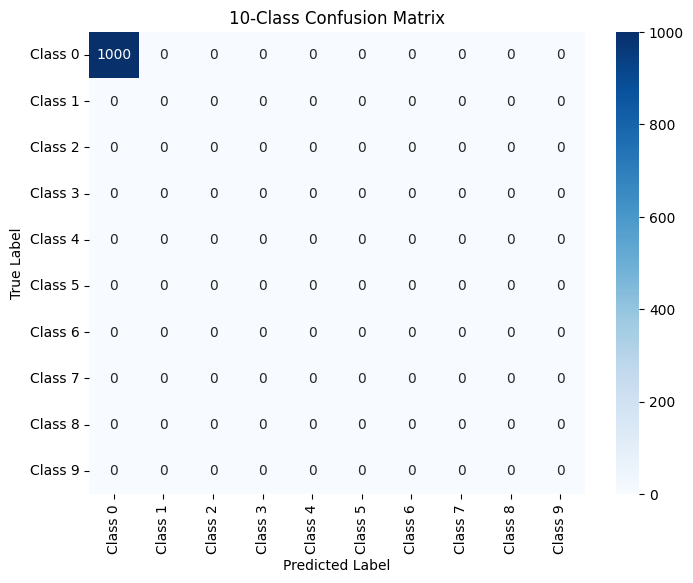

In [122]:
# 1. Generate predictions
predictions = model.predict(X_test)
y_pred_classes = np.argmax(predictions, axis=1)
y_true_classes = np.argmax(y_test, axis=1)  # Change to y_test if it is already integer labels

# 2. Compute the matrix using explicit 10x10 labels
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=list(range(10)))

# 3. Render the plot safely
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[f"Class {i}" for i in range(10)],
    yticklabels=[f"Class {i}" for i in range(10)],
    ax=ax
)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("10-Class Confusion Matrix")
plt.show()


In [111]:
y_test['attack_type_encoded'].unique()

array([0, 1, 7, 3, 8, 6, 4, 9, 5, 2])

In [117]:
import numpy as np
import pandas as pd

# 1. Safely flatten your labels to a 1D structure
if isinstance(y_df, (pd.DataFrame, pd.Series)):
    # If it's a Pandas object, use value_counts
    print("--- Pandas Label Distribution ---")
    print(y_df.value_counts())
else:
    # If it's a NumPy array or list, flatten it to 1D
    y_flat = np.array(y_df).ravel()
    print("--- NumPy Label Distribution ---")
    print("Flat shape:", y_flat.shape)

    if len(y_flat) > 0 and isinstance(y_flat[0], (np.integer, int)):
        print("Class counts:", np.bincount(y_flat))
        print("Unique classes found:", np.unique(y_flat))
    else:
        # If it contains strings or one-hot structures
        unique, counts = np.unique(y_flat, return_counts=True)
        print("Class counts:", dict(zip(unique, counts)))


--- Pandas Label Distribution ---
attack_type_encoded
0                      9600
1                       108
7                        81
8                        64
9                        34
4                        28
5                        27
3                        26
6                        22
2                        10
Name: count, dtype: int64
